# LLM Application Fundamentals with Langchain

## 01. The basics

This is the first in a series of AI native courses that I followed on datacamp

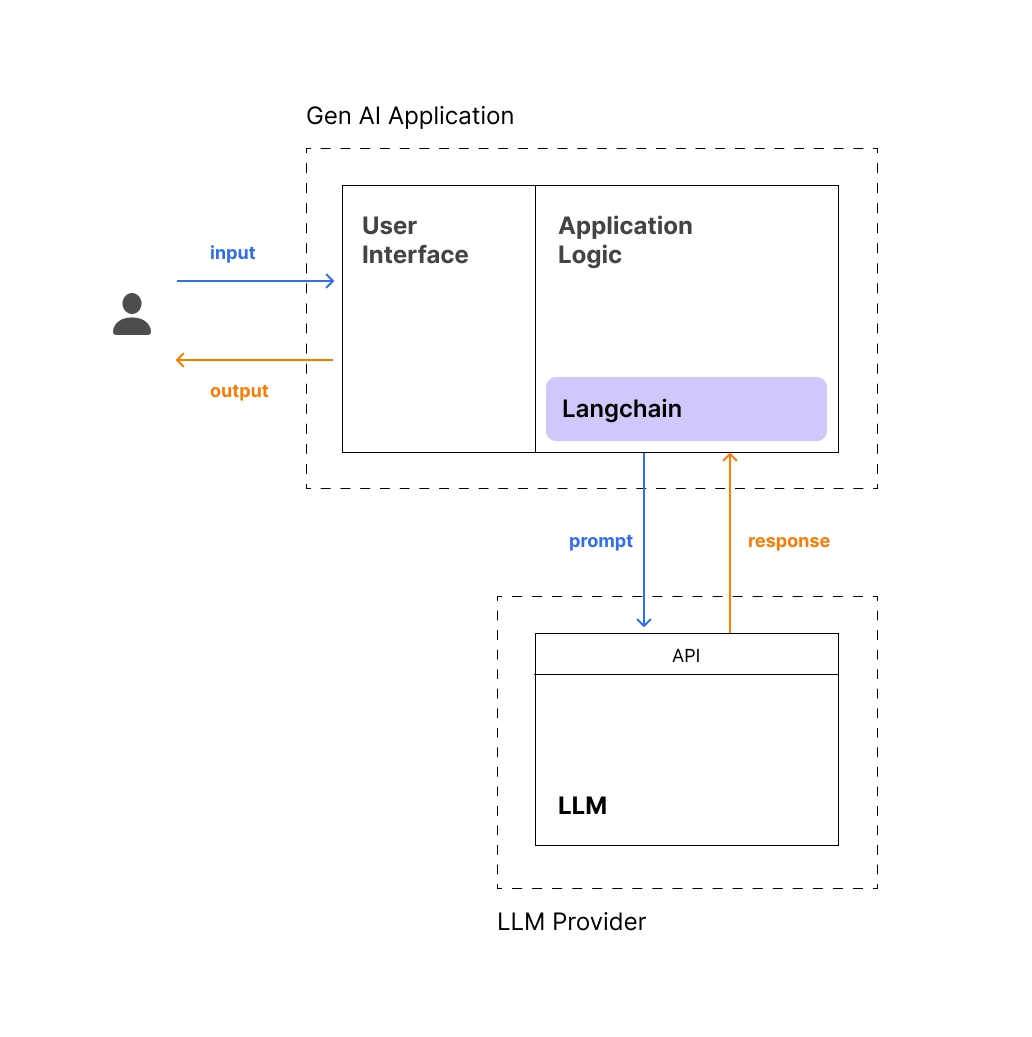

Here's your code editor — this is where you'll build the full application step by step.

First things first: importing the components we need from LangChain. You'll need two imports:

- `init_chat_model` from `langchain.chat_models` — this is how we'll connect to and interact with an LLM
- `PromptTemplate` from `langchain_core.prompts` — this gives us tools to manage and structure prompts

No need to worry about installation — the Optima platform handles that automatically in the background.

Go ahead and add those two imports to the editor and hit Submit.

In [1]:
# Your code goes here
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate
import os

from dotenv import load_dotenv

load_dotenv()  # Loads API keys from .env file
# OPENAI_API_KEY=sk-proj-...  (stored in .env, never hardcoded)

prompt_template_str = """
Your task is to explain the concept of **{concept}** to me in a way that is:

1. Clear and intuitive
2. Concise (in under 100 words)
3. Tailored specifically to me and what I already know

Use the following information about me to personalize your explanation:

- Background: Model risk manager with deep experience in financial markets and exotic interest rate frameworks
- Current project: ALM and pipeline risk — managing interest rate options for mortgage buyers
- Technical level: Strong quantitative background (stochastic calculus, derivatives pricing)

The personalization should be subtle and natural. Avoid forced references that don't genuinely enhance understanding.
"""

# Create a prompt template
prompt_template = PromptTemplate.from_template(prompt_template_str)

# Define the input variable
concept = "pipeline fallout rate"

# Format the prompt with the input variable
prompt = prompt_template.format(concept=concept)

print(prompt)



Your task is to explain the concept of **pipeline fallout rate** to me in a way that is:

1. Clear and intuitive
2. Concise (in under 100 words)
3. Tailored specifically to me and what I already know

Use the following information about me to personalize your explanation:

- Background: Model risk manager with deep experience in financial markets and exotic interest rate frameworks
- Current project: ALM and pipeline risk — managing interest rate options for mortgage buyers
- Technical level: Strong quantitative background (stochastic calculus, derivatives pricing)

The personalization should be subtle and natural. Avoid forced references that don't genuinely enhance understanding.



- `PromptTemplate.from_template()` turns your string into a reusable template object
- `.format()` replaces `{concept}` with the actual value — in this case "pipeline fallout rate", which is directly relevant to your ALM project
- `print(prompt)` lets us see exactly what gets sent to the LLM

Now for the most exciting part — actually calling the LLM. Add the following block after your prompt formatting code:

In [2]:
# Create a model interface
model = init_chat_model("gpt-4o-mini", model_provider="openai")

# Call the model with the prompt
response = model.invoke(prompt)

# Print the generated content
print(response.text)


The pipeline fallout rate measures the percentage of mortgage loan applications that drop out before closing, often due to rising interest rates. In your ALM project, understanding this metric helps assess the impact of interest rate fluctuations on your pipeline. A higher fallout rate can signal increased risk in your hedging strategies for mortgage options, similar to tracking volatility in financial derivatives. By quantifying this rate, you can better model the cash flow dynamics and potential mismatches in your interest rate exposure.


- `init_chat_model()` creates a **model interface** for the specified model and provider — one line to connect to any LLM
- `model.invoke()` sends the prompt and returns the LLM's response
- `response.text` is the actual generated content

`why do we use PromptTemplate and not just and f string to achieve the same`

You could use an f-string and it would work for simple cases. But PromptTemplate gives you several advantages:

- **Reusability** — you define the template once and call .format() with different inputs, keeping your code clean and DRY
- **Input validation** — LangChain checks that all required variables are provided before the prompt is sent, catching missing inputs early
- **Chain integration** — PromptTemplate objects plug directly into LangChain's chain abstractions (which we'll use later in the course), whereas raw f-strings don't
- **Clarity of intent** — it makes explicit that this string is a prompt template, not just any formatted string

For a one-off script, an f-string is fine. But for production LLM apps, PromptTemplate is the right tool.

### Gradio

Now let's add a proper UI. Since building front-end interfaces isn't the focus of this course, we'll use **Gradio** — a Python library that creates functional web interfaces with minimal code and zero frontend experience required. It's widely used in the ML/AI space for exactly this purpose.

Are you familiar with Gradio at all?

`No, let's go through it`

**Gradio** is an open-source Python library by Hugging Face that lets you build simple web interfaces with just a few lines of Python — no HTML, CSS, or JavaScript needed. It's specifically designed for ML and AI practitioners to quickly demo their models and apps.

For our app, it'll give us:

- An **input textbox** where users type a concept
- An **output textbox** that displays the LLM's explanation

Any questions about Gradio before we wire it up?

Before we add the Gradio code, we need to wrap our LLM logic in a function so Gradio can call it when the user submits input.

Here's what I'd like you to do:

- Create a new function called `generate_explanation()` that takes `input_text` as an argument
- Move your prompt formatting and model calling code inside the function
- Have the function return `response.text`
- Keep `prompt_template` and `model` initialization outside the function
- Remove the print statement

In [3]:
# Your code goes here
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate
import os

from dotenv import load_dotenv

load_dotenv()  # Loads API keys from .env file
# OPENAI_API_KEY=sk-proj-...  (stored in .env, never hardcoded)

prompt_template_str = """
Your task is to explain the concept of **{concept}** to me in a way that is:

1. Clear and intuitive
2. Concise (in under 100 words)
3. Tailored specifically to me and what I already know

Use the following information about me to personalize your explanation:

- Background: Model risk manager with deep experience in financial markets and exotic interest rate frameworks
- Current project: ALM and pipeline risk — managing interest rate options for mortgage buyers
- Technical level: Strong quantitative background (stochastic calculus, derivatives pricing)

The personalization should be subtle and natural. Avoid forced references that don't genuinely enhance understanding.
"""

# Create a prompt template
prompt_template = PromptTemplate.from_template(prompt_template_str)

# Create a model interface
model = init_chat_model("gpt-4o-mini", model_provider="openai")

def generate_explanation(input_text: str):

  # Format the prompt with the input variable
  prompt = prompt_template.format(concept=input_text)

  # Call the model with the prompt
  response = model.invoke(prompt)
  
  return response.text


That's exactly right! Clean structure:

- `prompt_template` and `model` initialized outside the function — created once, reused on every call
- `generate_explanation()` takes input_text, formats the prompt, calls the model, and returns the response text

In [4]:
generate_explanation("What are the key model risks in alm pipeline model")

"In an ALM pipeline model, key model risks include parameter estimation error, which affects interest rate forecasts and impacts options pricing; model specification risk, where incorrect assumptions about the underlying processes can misrepresent risk; and calibration risk, particularly in volatile environments where historical data may not reflect future dynamics. Additionally, correlation risks between interest rates and mortgage prepayments can lead to misjudged liquidity positions. Given your expertise, it's crucial to regularly validate model assumptions and stay adaptable to evolving market conditions."

Now let's add the Gradio interface. Here's the code to add after your function:

In [5]:
import gradio as gr

demo = gr.Interface(
    fn=generate_explanation,
    inputs=[gr.Textbox(label="Concept", lines=1)],
    outputs=[gr.Textbox(label="Explanation", lines=5)],
    flagging_mode="never",
    title="Concept Explainer",
    description="Enter any concept and get a personalized explanation"
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


`gr.Interface()` wires up your function to a web UI — `fn` is called whenever the user submits input, and the return value is displayed in the output box. The launch() is commented out since Optima handles that automatically.

Your app is live in the output tab! 🎉 Go ahead and try it out — type in **"pipeline fallout rate"**, **"convexity of MBS"**, or any concept from your ALM work and see how it responds.

If you make any changes to the code, just re-submit for them to reflect in the app. Take your time experimenting, and hit Continue when you're ready to wrap up!

`but if you have two inputs how does it now which one to use as what argument`

Exactly the right thing to wonder! With two inputs, the order in the inputs list maps directly to the order of function arguments.

For example, if your function was generate_explanation(concept, audience), you'd write:

```python
inputs=[gr.Textbox(label="Concept"), gr.Textbox(label="Audience")]
```

Gradio passes the first textbox value to concept and the second to audience — purely positional, just like calling a Python function with positional arguments. The labels are just for display; they don't affect the mapping.

You've built a complete, working Gen AI application — time to lock in what you learned! Go through this summary at your own pace. After that, you'll get to practice building your own app from scratch.

## Summary - LLM Application Architecture

#### Most LLM applications share three core components:

- User Interface: Provides a way for users to input data and view responses
- Application Logic: Constructs prompts, communicates with the LLM via API, and processes responses
- LLM Provider: External service that processes prompts and generates responses

#### LangChain

- A framework that has become a standard in the space for building LLM applications, providing a design methodology and modular components
- Key benefits: development speed (pre-built components), provider abstraction (switch between OpenAI, Anthropic, etc. without code changes), and an active open-source community

#### Prompt Templates

- Create reusable prompts with variable placeholders using PromptTemplate:
```python

from langchain_core.prompts import PromptTemplate

prompt_template_str = "... {input_text} ..."
prompt_template = PromptTemplate.from_template(prompt_template_str)
prompt = prompt_template.format(input_text="your value")
```

- Template variables (e.g., {input_text}) are replaced with actual values at runtime using .format()

#### Model Interface

- Initialize a model and call it using LangChain:
```python
from langchain.chat_models import init_chat_model

model = init_chat_model("gpt-4o-mini", model_provider="openai")
response = model.invoke(prompt)
print(response.text)
```

- init_chat_model() creates a model interface for a given provider
- model.invoke() sends the prompt and returns the response
- response.text contains the generated content

#### API Key Management

- Each LLM provider requires an API key for authentication — never hardcode keys in your code
- Store keys in a .env file and load with dotenv:
```python
from dotenv import load_dotenv

load_dotenv()
```

- LangChain automatically reads provider-specific environment variables (e.g., OPENAI_API_KEY)
- Add .env to .gitignore to keep keys out of your codebase

## A financial acronym explainer!

Here's the plan:

- Input: a financial acronym or term (e.g., "IRRBB", "FRTB", "CVA")
- Output: a concise, plain-language explanation tailored to a risk professional
Let's build it!

Here's your fresh editor. Your task is to **build the financial acronym explainer from scratch**:

1. Create a prompt template with a variable placeholder for the user's input
2. Create a PromptTemplate object using LangChain
3. Initialize the model with gpt-4o-mini via OpenAI
4. .Format the prompt, call the model, and print the response

You can scroll up to reference the code we wrote earlier, or use the Notes panel for the key patterns. Give it a go — no hints upfront, I want to see what you can build independently. Hit Submit when ready!

In [6]:
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate
import gradio as gr

# Model: gpt-4o-mini | Provider: openai
model = init_chat_model("gpt-4o-mini")

prompt_template_str = """
You are a financial expert assistant helping a model risk manager in financial markets.

Your task is to explain the following financial term or acronym: **{input}**

Your explanation must be:
1. Concise (under 100 words)
2. In plain language — avoid unnecessary jargon
3. Tailored to a risk professional with a strong quantitative background
4. Structured as: definition first, then practical relevance to risk management

Do not add introductory phrases like "Sure!" or "Great question!". Go straight to the explanation.
"""

prompt_template = PromptTemplate.from_template(prompt_template_str)

def generate_response(input_str: str):
  # create the prompt
  prompt = prompt_template.format(input=input_str)

  # call the model
  response = model.invoke(prompt)

  return response.text

demo = gr.Interface(
    fn=generate_response,
    inputs=[gr.Textbox(label="Financial Term or Acronym", lines=1)],
    outputs=[gr.Textbox(label="Explanation", lines=5)],
    flagging_mode="never",
    title="Financial Acronym Explainer",
    description="Enter any financial term or acronym for a concise, risk-professional explanation"
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


## Application development

Welcome! Great to have you here for this lesson on Application Development — the second step in your journey through LLM Application Fundamentals.

Building on your first AI app, you'll go deeper into what it takes to make that app production-ready:

- **Structured outputs** — getting reliable, typed data back from the LLM instead of raw text
- **Input handling** — validating and sanitizing user input before it ever reaches the model
- **Error handling** — gracefully managing the failures that inevitably happen with live APIs

Given your goal of building "chatting with your data" applications for financial data, structured outputs in particular will be directly relevant — they're the backbone of reliable LLM pipelines. Let's dive in!

To ground what we're building today, let's start with a concrete problem.

**E-commerce apps receive thousands of reviews every day** — each one packed with valuable customer feedback about pricing, delivery, app usability, product quality, and more.

The challenge:

- **Manually reading and categorizing** all those reviews is completely impractical at scale
- **Simple keyword matching misses nuance** — it can't detect sentiment, implied suggestions, or topic-specific opinions
- Without systematic analysis, businesses **miss critical signals** about what's working and what isn't

What we want is a way to extract meaningful, structured insights from these reviews automatically and reliably. Does this make sense so far?

`yes` 

```
review_id: "R12345"

date: "2025-01-01"

rating: "★★★☆☆ (3 stars)"

"text": "I love the discount program in this app - saved 30% on my last
order! However, the search functionality is really frustrating.
Results are rarely relevant to what I'm looking for. They should
implement category filters and improve their search algorithm."
```

Here's what a typical review looks like in our system. A few things worth noting:

- A single review can **address multiple topics** — UI/UX, delivery, customer service, discounts, etc.
- The reviewer may have a **different sentiment for each topic** — positive about one thing, negative about another
- They may also be **reporting specific problems** or suggesting concrete improvements

This is exactly what makes reviews rich but hard to process with simple rules. The structure we need to extract is hiding inside unstructured text. Make sense?

`yes`

So what exactly do we need to extract from each review to power that dashboard? There are four key attributes:

- **Overall sentiment** — is the review positive, negative, or mixed overall?
- **Notable phrases** — verbatim snippets that capture the most important feedback
- **Individual opinions** — one per topic mentioned, each with:
  - The topic being discussed (e.g., search, discounts)
  - The sentiment toward that topic
  - Any problem reported
  - Any solution suggested

Extracting this kind of nuanced, multi-level information is exactly where LLMs shine — something neither manual reading at scale nor keyword matching can reliably deliver.

Now, the natural next question is: how do we get the LLM to return this in a consistent, machine-readable format? Let's start with what a naive first attempt looks like.


This is the kind of code you built in the previous lesson — a prompt template that asks the LLM to extract the exact attributes we identified, invoked with llm.invoke(). The prompt on lines 16-27 reflects precisely those attributes: overall sentiment, notable phrases, and individual opinions.

Go ahead and run the code to see what comes back. If anything about the code is unclear, feel free to ask!

In [7]:
# Setup
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate


def get_response(prompt_template_str, review):
    prompt_template = PromptTemplate.from_template(prompt_template_str)
    prompt = prompt_template.format(review=review)
    response = llm.invoke(prompt)
    return response.text


llm = init_chat_model("gpt-4o-mini")

# Define the Prompt Template
prompt_template_str = """
Given the following review:
{review}
Extract the following attributes from this review:
- The overall sentiment of the review (positive, negative, mixed)
- Notable phrases that capture key feedback
- Individual opinions on specific topics, each with:
  - The topic being discussed
  - The sentiment toward that topic
  - Any problem reported
  - Any solution suggested
"""

# Define the review string
review_str = """
{
    "review_id": "R12345",
    "date": "2025-01-01",
    "rating": "★★★☆☆ (3 stars)",
    "text": "I love the discount program in this app - saved 30% on my last order! However, the search functionality is really frustrating. Results are rarely relevant to what I'm looking for. They should implement category filters and improve their search algorithm."
}
"""

# Get the model's response for the review
response_content = get_response(prompt_template_str, review_str)
print(response_content)

Based on the provided review, here’s the extracted information:

### Overall Sentiment
- **Sentiment:** Mixed

### Notable Phrases
- "I love the discount program in this app - saved 30% on my last order!"
- "However, the search functionality is really frustrating."
- "Results are rarely relevant to what I'm looking for."
- "They should implement category filters and improve their search algorithm."

### Individual Opinions on Specific Topics

1. **Topic:** Discount Program
   - **Sentiment:** Positive
   - **Problem Reported:** None reported, the user is satisfied with this feature.
   - **Solution Suggested:** None, as the user is happy with the discount program.

2. **Topic:** Search Functionality
   - **Sentiment:** Negative
   - **Problem Reported:** Search results are rarely relevant to what the user is looking for; it's described as frustrating.
   - **Solution Suggested:** Implement category filters and improve the search algorithm.


The output looks pretty good — the LLM correctly identified the **mixed sentiment**, pulled out **relevant notable phrases**, and even captured the **problem and suggested solution** for the search topic.

But here's the problem: this is **plain text**. For a dashboard application, you need to programmatically access these values — loop over the opinions, filter by sentiment, count problems, etc. With raw text like this, you'd have to write a custom parser to extract the data, and that parser would be **fragile** — any slight change in how the LLM formats its response would break it.

What we really want is for the LLM to return a **structured, validated Python object** that we can work with directly. That's exactly what structured output gives us — let's explore how.

There are three main formats for structuring LLM outputs:

- **JSON** — parses the output into a dictionary. Simple and flexible, but no type safety or runtime validation.
- **TypedDict** — a typed dictionary with defined keys and value types. Adds type hints over plain JSON, but still no runtime validation.
- **Pydantic** — a Python class with typed fields, validation rules, and helpful error messages.

Gives you the strongest guarantees: type safety, runtime validation, and IDE autocompletion.
Pydantic has become the de facto standard for structured output in LLM applications — it's deeply integrated with LangChain and modern LLM tooling, so that's what we'll use.

Are you already familiar with Pydantic?

`No`

No problem! Before we jump into code, we need to design the data model first — what fields do we want, what types should they be, how are they nested? That's the blueprint Pydantic will enforce.

Let's look at what our desired output structure looks like as a JSON object, then we'll translate it into a Pydantic model.

Here's the target output structure for our review analyzer. Let's walk through it:

- `review_id` — a string identifying the review
- `overall_sentiment` — the top-level sentiment: positive, negative, or mixed
- `notable_phrases` — a list of strings capturing key verbatim feedback
- `opinions` — a list of objects, one per topic, each with:
    - `topic` — what's being discussed
    - `sentiment` — how the reviewer feels about it
    - `problem` — any issue reported
    - `suggested_solution` — any fix proposed

Notice how this maps directly to the attributes we identified earlier. The nested opinions list is the key design decision here — each topic gets its own structured entry rather than being buried in a blob of text.

This process of defining structures that represent the data your application needs is called data modeling. Getting this right upfront makes your code more robust and maintainable — and it's what tells the LLM exactly what to return. Let's now translate this into actual Pydantic code.

In [9]:
from pydantic import BaseModel, Field
from typing import Optional

class Opinion(BaseModel):
    topic: str = Field(description="The topic of the opinion")
    sentiment: str = Field(description="The sentiment of the opinion")
    problem: Optional[str] = Field(description="The problem of the opinion, if any.")
    suggested_solution: Optional[str] = Field(
        description="The suggested solution of the opinion, if any."
    )


Here's how that JSON structure translates into Pydantic. Let's start with the Opinion class on lines 10-16 — it represents a single topic opinion.

Each field is defined with a type annotation and a Field() that describes what it represents:

- `topic: str` — required string field
- `sentiment: str` — required string field
- `problem: Optional[str]` — optional, since not every opinion has a reported problem
- `suggested_solution: Optional[str]` — also optional

The `Field(description="...")` on each field is important — it tells the LLM what that field represents, which is how the model knows what to populate it with.

Does the structure of `Opinion`make sense so far?

`yes`

In [10]:
class StructuredReview(BaseModel):
    review_id: str = Field(description="The ID of the review", pattern=r"^R\d{5}$")
    overall_sentiment: str = Field(description="The sentiment of the review")
    notable_phrases: list[str] = Field(description="The notable phrases of the review")
    opinions: list[Opinion] = Field(description="The opinions of the review")


Now look at the StructuredReview class, which is the top-level model.

- `review_id: str` = `Field(pattern=r"^R\d{5}$")` — a required string, but with a regex pattern constraint ensuring it matches the format R12345. Pydantic will reject any value that doesn't match.
- `overall_sentiment: str` — required string
- `notable_phrases: list[str]` — a list of strings
- `opinions: list[Opinion]` — a list of nested Opinion objects, which is exactly the nesting we designed

So the two classes work together: StructuredReview is the outer shell, and Opinion is the building block for the nested list.

Can you see how this maps to the JSON structure we designed earlier?

In [11]:
from langchain.chat_models import init_chat_model
from pydantic import BaseModel, Field
from typing import Optional
from devtools import pprint


# Define the Pydantic model


class Opinion(BaseModel):
    topic: str = Field(description="The topic of the opinion")
    sentiment: str = Field(description="The sentiment of the opinion")
    problem: Optional[str] = Field(description="The problem of the opinion, if any.")
    suggested_solution: Optional[str] = Field(
        description="The suggested solution of the opinion, if any."
    )


class StructuredReview(BaseModel):
    review_id: str = Field(description="The ID of the review", pattern=r"^R\d{5}$")
    overall_sentiment: str = Field(description="The sentiment of the review")
    notable_phrases: list[str] = Field(description="The notable phrases of the review")
    opinions: list[Opinion] = Field(description="The opinions of the review")


llm = init_chat_model(model="gpt-4.1-mini", temperature=0)

# Create a structured LLM that returns validated Pydantic objects
structured_llm = llm.with_structured_output(StructuredReview)


# This is the schema that gets sent to the LLM
pprint(StructuredReview.model_json_schema())


{
    '$defs': {
        'Opinion': {
            'properties': {
                'topic': {
                    'description': 'The topic of the opinion',
                    'title': 'Topic',
                    'type': 'string',
                },
                'sentiment': {
                    'description': 'The sentiment of the opinion',
                    'title': 'Sentiment',
                    'type': 'string',
                },
                'problem': {
                    'anyOf': [
                        {
                            'type': 'string',
                        },
                        {
                            'type': 'null',
                        },
                    ],
                    'description': 'The problem of the opinion, if any.',
                    'title': 'Problem',
                },
                'suggested_solution': {
                    'anyOf': [
                        {
                            'type': 'string

Now that the models are defined, the next step is connecting them to the LLM. That's what `with_structured_output()` does on line 29.

It takes your Pydantic model and configures the LLM to:

1. Automatically instruct itself to match that schema — no format instructions needed in your prompt
2. Parse and validate the response internally — returning a typed Pydantic object directly, with no manual parsing code

Line 33 then prints the JSON schema that gets sent to the LLM under the hood — this is how the model knows exactly what fields to populate.

Notice how the schema captures everything from our Pydantic models:

- The required array at the bottom lists review_id, overall_sentiment, notable_phrases, and opinions — exactly our four top-level fields
- Opinion is defined under $defs with all its properties and descriptions intact
- The opinions field references Opinion via `$ref` — that's how the nesting is expressed
- Optional fields like problem show anyOf: [string, null] — meaning the LLM can return either a string or null

This is what gets sent to the LLM when you call structured_llm.invoke() — the model uses it as a contract for what to return. No format instructions in your prompt needed. Ready to see the full pipeline in action?

In [12]:
review_text = """
review_id: R12345
date: 2025-01-01
rating: ★★★☆☆ (3 stars)
text: I love the discount program in this app - saved 30% on my last order! However, the search functionality is really frustrating. Results are rarely relevant to what I’m looking for. They should implement category filters and improve their search algorithm.
"""

prompt = f"Extract structured data from this review:\n{review_text}"

# Invoke and get a validated Pydantic object directly
structured_review = structured_llm.invoke(prompt)

pprint(structured_review)

# Access fields directly
print(f"\nReview ID: {structured_review.review_id}")
print(f"Sentiment: {structured_review.overall_sentiment}")
print(f"Number of opinions: {len(structured_review.opinions)}")

StructuredReview(
    review_id='R12345',
    overall_sentiment='Mixed',
    notable_phrases=[
        'love the discount program',
        'saved 30% on my last order',
        'search functionality is really frustrating',
        'results are rarely relevant',
        'implement category filters',
        'improve their search algorithm',
    ],
    opinions=[
        Opinion(
            topic='Discount program',
            sentiment='Positive',
            problem=None,
            suggested_solution=None,
        ),
        Opinion(
            topic='Search functionality',
            sentiment='Negative',
            problem='Results are rarely relevant to what the user is looking for',
            suggested_solution='Implement category filters and improve the search algorithm',
        ),
    ],
)

Review ID: R12345
Sentiment: Mixed
Number of opinions: 2


Exactly right — those are the core risks:

- Malformed input — invalid formats, missing fields, or wrong data types that cause errors downstream
- Dangerous input — prompt injection attacks where malicious users try to manipulate the LLM's behavior
- Wasted API calls — sending empty or nonsensical input wastes tokens and money, and LLMs are prone to hallucinating plausible-sounding but wrong responses when given poor input

The diagram here captures the full flow: raw input goes through **validation** first — reject it early if it doesn't meet requirements — then **sanitization** to clean it up, and finally **prompt interpolation** before it reaches the LLM.

Three components work together:

- **Validation** — enforce requirements and reject bad data
- **Sanitization** — clean inputs to prevent security issues
- **Prompt Formatting** — properly structure the cleaned input in the prompt template

Let's look at validation in practice with a concrete example from our review pipeline.

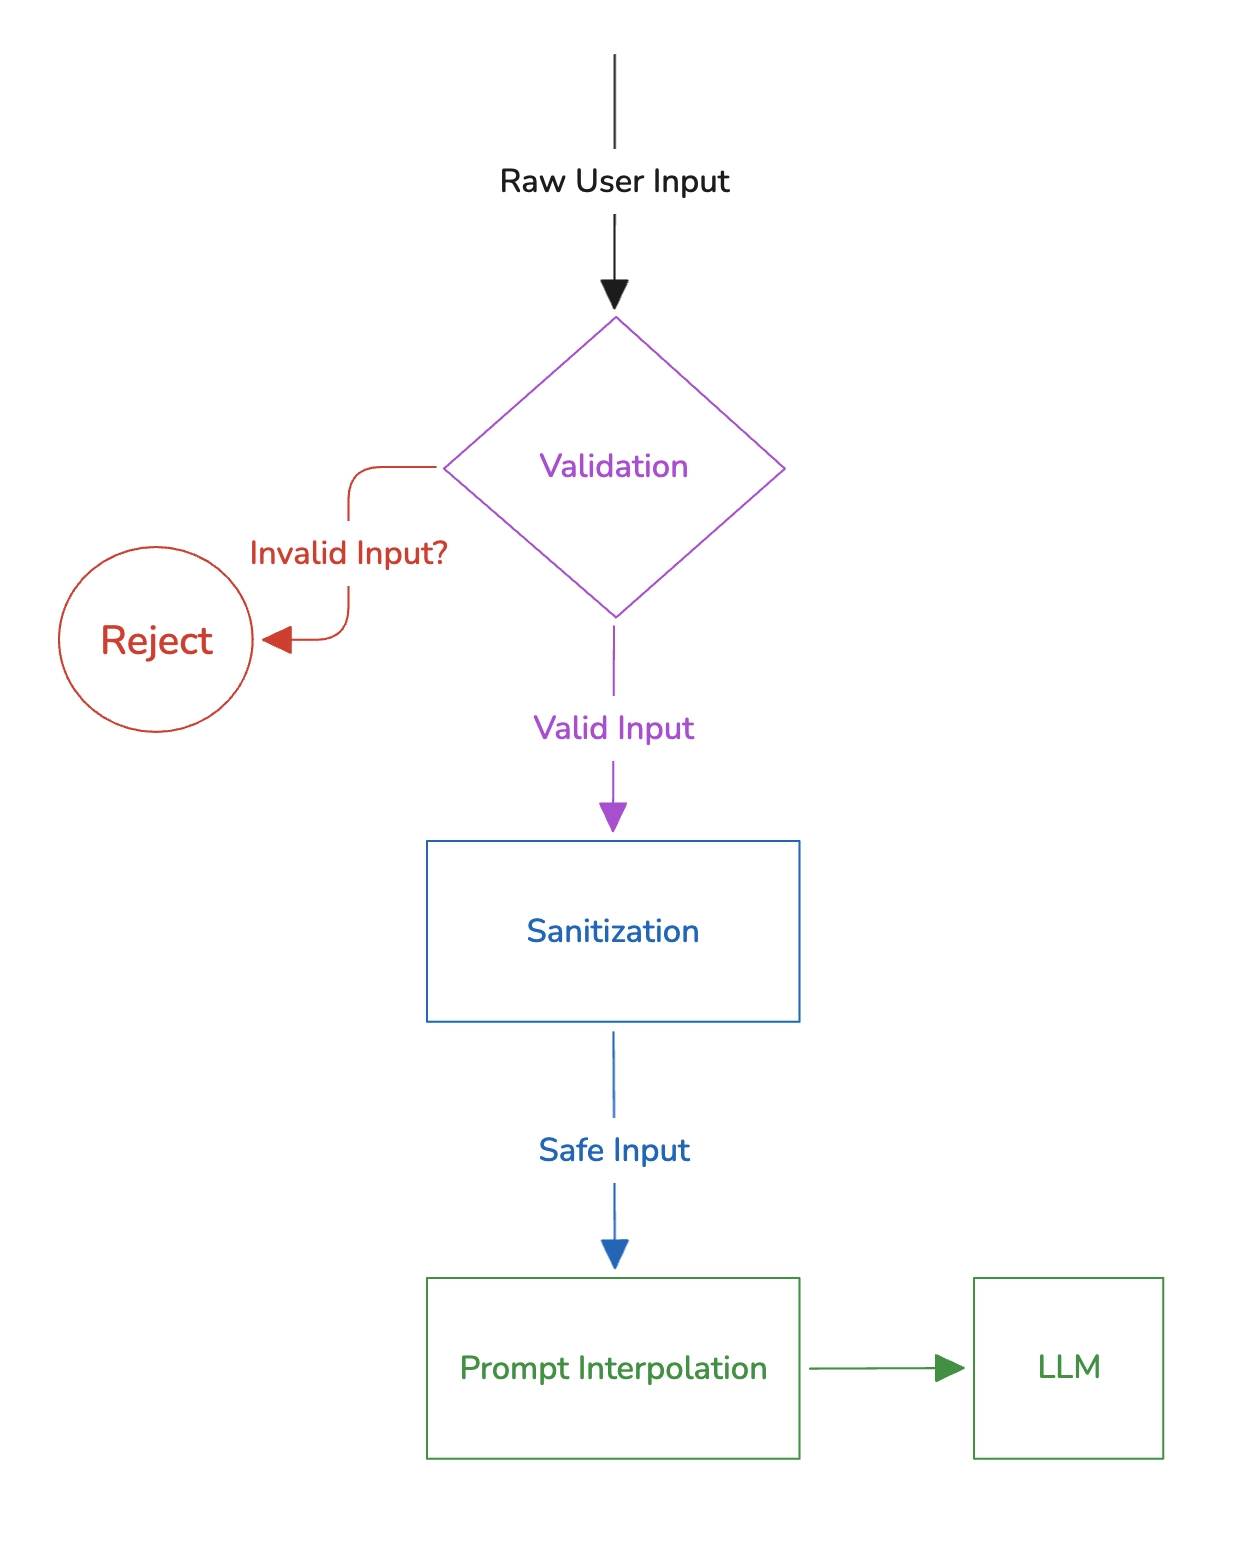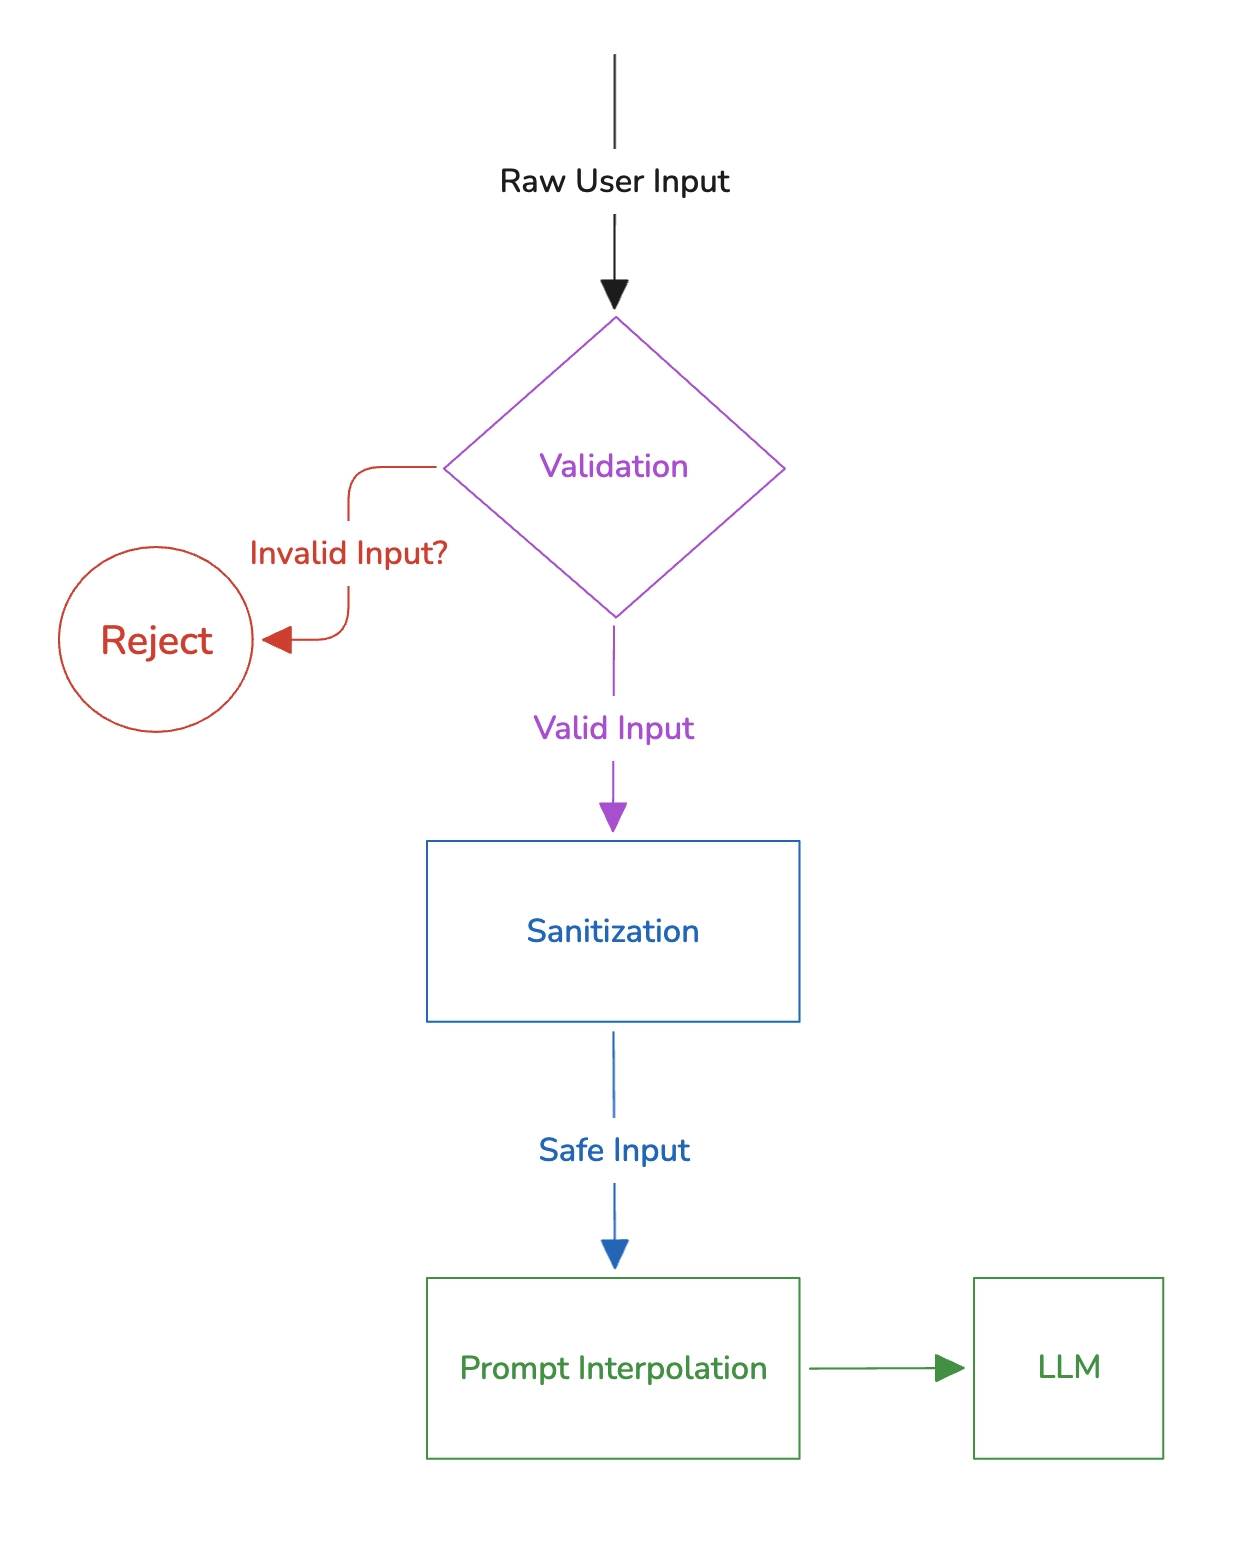

Here's where it gets elegant — the same Pydantic library we used for structured outputs can also validate inputs. No new tools needed.

We define a Review model on lines 6-16 with constraints that directly address the issues we just identified:

 - review_id — a pattern constraint enforcing the R12345 format
- rating — a pattern constraint enforcing the star format string
- date — typed as datetime.date, so anything non-parseable like "1 month ago" is rejected
- text — min_length=1 ensures empty strings are rejected

Line 28 then calls model_validate_json() — this is how you validate input against the model. Run it to see what happens with our invalid review!

**THE CODE BELOW MUST GIVE AN ERROR**

In [13]:
from pydantic import BaseModel, Field
import datetime
from devtools import pprint


class Review(BaseModel):
    review_id: str = Field(description="The ID of the review", pattern=r"^R\d{5}$")
    rating: str = Field(
        description="The rating of the review", pattern=r"^★{1,5}☆{0,4} \(\d stars\)$"
    )
    date: datetime.date = Field(
        description="The date of the review", format="YYYY-MM-DD"
    )
    text: str = Field(
        description="The text of the review", min_length=1, max_length=1000
    )


invalid_review_json = """
{
  "review_id": "",
  "rating": 3,
  "date": "1 month ago",
  "text": ""
}
"""

review = Review.model_validate_json(invalid_review_json)

pprint(review)

/tmp/ipykernel_30760/25776402.py:11: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'format'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  date: datetime.date = Field(


ValidationError: 4 validation errors for Review
review_id
  String should match pattern '^R\d{5}$' [type=string_pattern_mismatch, input_value='', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/string_pattern_mismatch
rating
  Input should be a valid string [type=string_type, input_value=3, input_type=int]
    For further information visit https://errors.pydantic.dev/2.13/v/string_type
date
  Input should be a valid date or datetime, invalid character in year [type=date_from_datetime_parsing, input_value='1 month ago', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/date_from_datetime_parsing
text
  String should have at least 1 character [type=string_too_short, input_value='', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/string_too_short

Pydantic caught all four issues and raised a ValidationError with a clear description of each:

- review_id — empty string doesn't match ^R\d{5}$
- rating — integer 3 is not a valid string
- date — "1 month ago" can't be parsed as a date
- text — empty string violates min_length=1

This is exactly what we want — the invalid review never reaches the LLM. In a real application, you'd wrap model_validate_json() in a try/except ValidationError block and return an appropriate error response to the user.

Now let's see the same model with a valid review to confirm it passes cleanly.

**CODE BELOW SHOULD RUN - No pydantic errors**

In [14]:
valid_review_json = """
{
  "review_id": "R12345",
  "rating": "★★★★☆ (4 stars)",
  "date": "2025-01-01",
  "text": "This is a great product!"
}
"""

review = Review.model_validate_json(valid_review_json)

pprint(review)



Review(
    review_id='R12345',
    rating='★★★★☆ (4 stars)',
    date=datetime.date(2025, 1, 1),
    text='This is a great product!',
)


A clean `Review` object — all fields pass validation and date is automatically parsed into a proper datetime.date object, ready for use in application logic.

To recap, Pydantic input validation gives you a consistent strategy for catching common issues:

- Empty inputs — min_length=1 rejects blank fields that waste resources
- Length limits — max_length prevents inputs that exceed token limits
- Format enforcement — pattern constraints catch malformed IDs, dates, phone numbers, etc.
- Type correctness — type annotations reject the wrong data types entirely
- Value ranges — gt, lt, ge, le constrain numeric fields to valid ranges

And the elegant part: you're already using Pydantic for structured outputs — the same patterns apply to inputs, so no extra tooling required.

Ready to move on to error handling?

`yes`

Anyone who's built with LLM APIs knows the frustration — you write clean code, craft a solid prompt, and then a 429 or 504 brings everything to a halt. These errors are inevitable when working with live APIs, but the good news is that most of them are predictable and handleable.

Proper error handling is what separates a fragile prototype from a reliable production application. We'll look at three categories of errors — each occurring at a different level of your stack, and each requiring its own approach to recover gracefully.

Here's a full overview of the six most common error types you'll encounter working with LLM APIs. Let's run through each briefly:

- Rate Limits (429) — too many requests in a short window. Fix: slow down, use exponential backoff, or upgrade your tier.
- Timeout (504) — request took too long. Fix: reduce input size or increase the timeout setting.
- Invalid Requests (400, 413) — malformed input or request too large. Fix: validate inputs before sending — exactly what we just built.
- Content Policy (400) — input or output violates the provider's content guidelines. Fix: filter content before submission.
- Quota Exceeded (429) — monthly usage limit hit. Fix: manage budget limits, set up alerts, or implement prompt caching.
- Server Overload (503, 529) — provider is under heavy load or down. Fix: retry with backoff, check the status page, or fall back to a simpler model.

**This should fail with 0.1 which is to short**


In [5]:
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate


def get_response(prompt_template_str, review):
    prompt_template = PromptTemplate.from_template(prompt_template_str)
    prompt = prompt_template.format(review=review)
    response = llm.invoke(prompt)
    return response.text


# Define the Prompt Template
prompt_template_str = """
Given the following review:
{review}
Convert the information in this review text into a structured JSON object.
Please include the sentiment of the review and any issues mentioned in the review.
Output the JSON object only, no other text or delimiters.
"""

# Define the review string
review_str = """
{
    "review_id": "R12345",
    "date": "2025-01-01",
    "rating": "★★★☆☆ (3 stars)",
    "text": "I love the discount program in this app - saved 30% on my last order! However, the search functionality is really frustrating. Results are rarely relevant to what I'm looking for. They should implement category filters and improve their search algorithm."
}
"""


# -----NEW CODE-----#

# Configure the LLM
llm = init_chat_model(
    model="gpt-4.1-nano",
    timeout=0.1,  # 100ms timeout
    max_retries=3,  # 3 retries
)

# Get the model's response for the review
response_content = get_response(prompt_template_str, review_str)
print(response_content)



{
  "review_id": "R12345",
  "date": "2025-01-01",
  "rating": 3,
  "text": "I love the discount program in this app - saved 30% on my last order! However, the search functionality is really frustrating. Results are rarely relevant to what I'm looking for. They should implement category filters and improve their search algorithm.",
  "sentiment": "mixed",
  "issues": [
    "ineffective search functionality",
    "irrelevant search results"
  ],
  "positive_aspects": [
    "discount program",
    "savings on order"
  ],
  "suggestions": [
    "implement category filters",
    "improve search algorithm"
  ]
}


Let's make the **timeout** error concrete. Here on lines 35-39, init_chat_model() is configured with two key parameters:

- timeout=0.1 — sets a 100ms limit, which is intentionally too short to trigger the error
- max_retries=3 — LangChain will automatically retry up to 3 times before giving up

These same parameters apply to rate limit and server overload errors too — retrying with backoff is the standard response for transient failures.

For errors like content policy or invalid requests, retrying won't help — you need to fix the root cause first, which is exactly why input validation matters.

And for quota exceeded or server overload, the best strategy is graceful degradation: fall back to a simpler model, display a clear message to the user, or switch providers entirely.

Run the code to see the timeout error in action!

There it is — `openai.APITimeoutError: Request timed out`. LangChain retried 3 times behind the scenes before finally giving up and surfacing the error.

In a real application, you'd catch this in a try/except block and either retry with a longer timeout, simplify the request, or return a graceful fallback message to the user instead of crashing.

That wraps up error handling. 

## Summary

### Pydantic Models

- Define data models using Python type annotations to specify expected structure
- Use BaseModel for both input validation and output parsing
- Add validation rules via Field() to enforce data quality
- Create nested models to represent complex hierarchical data

```python
from pydantic import BaseModel, Field
from typing import Optional


class SubItem(BaseModel):
    name: str = Field(description="Item name")
    score: float = Field(gt=0, le=10, description="Rating score")
    note: Optional[str] = Field(default=None, description="Optional note")


class Result(BaseModel):
    id: str = Field(pattern=r"^[A-Z]\d{4}$", description="Unique ID")
    summary: str = Field(description="Brief summary")
    tags: list[str] = Field(description="Relevant tags")
    items: list[SubItem] = Field(description="Detailed sub-items")
```

### Pydantic Field Types and Constraints

- Common field types and constraints

```python
# Common field types and constraints
required_string = str  # Required by default
optional_string: Optional[str] = None  # Using Optional from typing
optional_with_default: str = "default value"
int_with_range = Field(gt=0, lt=100)  # Greater than 0, less than 100
validated_string = Field(
    pattern=r"^[A-Z]\d{3}$")  # Regex pattern validation
validated_date = Field(format="YYYY-MM-DD")  # Date format validation
string_with_length = Field(min_length=1,
                           max_length=1000)  # Length constraints
list_field: list[str]  # List of strings
nested_model: list[SubModel]  # List of nested models
```
- For more field types and validation options, refer to the Pydantic documentation

### Structured Output

- Most practical LLM applications require structured outputs, not plain text
- `with_structured_output()` connects a Pydantic model to the LLM — no manual parsing or format instructions needed
- Returns validated Pydantic objects with typed fields you can access directly
```python
from pydantic import BaseModel


class YourModel(BaseModel):
    field_one: str
    field_two: int
    # ... other fields


structured_llm = llm.with_structured_output(YourModel)
result = structured_llm.invoke(prompt)  # Returns validated Pydantic object
```

### Input Handling

- The process of preparing, validating, and formatting user inputs before sending to an LLM
- Prevents hallucinations, preserves data integrity, and optimizes token usage
- Use Pydantic models to validate structured inputs before processing
```python
from pydantic import BaseModel, Field, ValidationError


class InputModel(BaseModel):
    text: str = Field(min_length=1, max_length=5000)
    category: str
    rating: int = Field(gt=0, le=5)


try:
    validated = InputModel.model_validate_json(raw_input)
except ValidationError as e:
    print(e)
```

### Data Modeling for LLM Applications

- Design data structures that represent your application's needs, independent of storage
- Properly modeled data ensures consistent outputs that fit application requirements
- Good models make code more robust, maintainable, and less error-prone
- Models serve as documentation of your app's data requirements

### Error Handling

- Code-level errors (429, 504, 400): Handle with retries, timeouts, and validation
- Account-level errors (401, 403, 429): Address with key rotation and quota management
- Provider-level errors (503, 529): Implement graceful degradation and fallbacks
- Use try/except blocks with specific exception handling for each error type

## Practice section

So here's our problem statement:

_Extract structured findings from model validation reports — capturing the overall outcome, risk rating, and a list of individual findings with their severity and recommended actions._

To summarize the output fields we'll work with:

- `model_id` — identifier of the model being validated
- `validation_outcome` — approved, conditionally approved, or rejected
- `overall_risk_rating` — low, medium, high, or critical
- `findings` — a list of individual findings, each with:
    - `description` — what the issue is
    - `severity` — critical, major, or minor
    - `remediation` — the recommended action

Now let's move to designing the actual models. Ready?

Let's design the models before writing any code. The text editor here has three sections to fill in:

- Output Model Design — the structured data the LLM should return
- Input Model Design — the data your application will accept
- Examples — two sample validation report excerpts that your app would process

A few questions to guide your thinking:

- What specific information do you want to extract from a validation report?
- Which fields are always present, and which might be absent?
- Are there any nested relationships in your data?

Fill in the three sections in the editor and submit when ready — don't worry about getting it perfect, we'll refine as needed!

#### high level data model

Here's your starting template. Your task is to build a complete structured LLM application that extracts findings from validation reports. Work through it in steps:

1. **Import** Pydantic and LangChain libraries
2. **Define** your Pydantic models — Finding and ValidationReport — matching your design
3. **Create** a structured LLM using with_structured_output()
4. **Write** a prompt describing the extraction task
5. **Invoke** the structured LLM and access the result fields
6. **Wrap** your call in a try/except block for error handling

Build and run frequently as you go — each run will show you what's working. You can check the Instructions tab for the task requirements anytime, and the Notes panel has code snippets from earlier if you need a reminder on syntax. Give it a go!

In [31]:
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field
from typing import Optional, Literal, List
from openai import APITimeoutError, APIError
from pydantic import ValidationError


from dotenv import load_dotenv
load_dotenv()

prompt_template_str = """
You are a helpful assistant that extracts structured data from a validation report. The output shoudl capture a
model risk assessment based on a validation report

{report_str}
"""


prompt_template = PromptTemplate.from_template(prompt_template_str)


class Finding(BaseModel):
    description: str = Field(description="concise description of the root cause risk of the finding")
    remediation: str = Field(description="steps to be taken to solve the root cause risk")
    severity: Literal["low", "medium", "high"] = Field(description="severity of the finding")

class RiskAssessment(BaseModel):
    model_id: str = Field(description="unique model id string in format MIxx where xx are digits",  pattern=r"^MI\d{2}$")
    validation_output: Literal["approved", "condiditionally approved","rejected"] = Field(description="Outcome of the validation process")
    overall_risk_rating: Literal["low", "medium", "high", "critical"] = Field(description="overall risk rating of the model assessment")
    findings: Optional[List[Finding]] = Field(description="list of findings")
    

model = init_chat_model("gpt-4o-mini", model_provider="openai", timeout=5, max_retries=3)

structured_llm = model.with_structured_output(RiskAssessment)


def get_response(input):
    prompt = prompt_template.format(report_str=input)
    try:
        response = structured_llm.invoke(prompt)
        return response
    except APITimeoutError as e:
        print(f"Request timed out: {e}")
    except APIError as e:
        print(f"API error: {e}")
    except ValidationError as e:
        print(f"Structured output validation failed: {e}")
    except Exception as e:
        print(f"Unexpected error: {e}")


# Example input
report_str = """
Model A has id MI01. 
There is only one medium finding related lack of substantiation of the assumptions that rates are lognormal. 
An emperical analysisis required to confirm with statistical test that the assumption is valid. 
The overall risk rating is low since there is only one medium finding. The model is approved.
"""


print(get_response(report_str))

model_id='MI01' validation_output='approved' overall_risk_rating='low' findings=[Finding(description='Lack of substantiation of the assumptions that rates are lognormal.', remediation='Conduct an empirical analysis with statistical tests to confirm that the assumption is valid.', severity='medium')]


## Conversational Fundamentals

Now we're stepping into something that'll be directly useful for your work: **building AI applications that can hold ongoing conversations.**

So far, you've been sending a single input and getting a single output back. That works well when everything the model needs is provided upfront. But for applications like chatbots, assistants, or — relevant to your work — a "chat with your data" SQL agent, the interaction naturally unfolds across **multiple back-and-forth exchanges**. Users clarify, refine, and build on what was said earlier.

In this lesson, you'll learn exactly how to build that: **multi-turn conversational AI applications** with proper history management. Let's get into it!

Here's what we'll build: a **diet planning chatbot** that holds a full conversation with the user to craft a personalized meal plan.

Users can ask things like:

- "I want to lose weight"
- "I need a high-protein diet for muscle building"
- "I'm allergic to nuts and dairy — what can I eat?"
- "How can I eat healthier on a tight budget?"

The chatbot follows a structured flow:

- Introduces itself and asks about the user's primary dietary goal
- Gathers information — preferences, restrictions, budget, cooking time — one topic at a time
- Generates a meal plan that satisfies all requirements
- Iterates on the plan based on feedback until the user is satisfied

This is a realistic pattern you'll recognize from your SQL agent work — gather context through conversation, then act on it. Clear so far?

`yes`

Let's look at how a multi-turn conversation is actually structured under the hood.

In code, a conversation is represented as an **ordered list of message objects**. Each message has a specific type:

- **System Message** — the first item in the list, always at index 0. It configures the model's behavior: its role, tone, and how it should interact. The user never sees it, but the model follows it throughout the entire conversation.
- **Human Message** — represents the user's input at each turn.
- **AI Message** — the model's generated response at each turn.

The model receives the **entire list** — from the system message through the most recent human message — and uses that full context to generate its next response.

In a moment, we'll look at a concrete example of this structure in action. Any questions on the three message types first?

Here's a real example of how this plays out for our diet chatbot. You can see the full conversation array — the system message sets up the assistant's role at the top, followed by alternating human and AI messages as the conversation unfolds.

Notice how the chatbot gathers information one topic at a time — dietary preferences, meal frequency, activity level, weight goal — before finally generating a meal plan. That's the system message doing its job, guiding the model's behavior throughout.

Take a moment to scan through it. Any questions about the structure before we move on?

In [34]:
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
messages = [
    SystemMessage(
        content="""
        You are a diet planning assistant that helps create balanced meal plans based on user goals,
        preferences and restrictions, while asking about a single topic at a time to avoid
        overwhelming the user.
        You should always ask about a single topic at a time to avoid overwhelming the user.""",
    ),
    HumanMessage(
        content="""Can you help me lose weight?""",
    ),
    AIMessage(
        content="""Absolutely! To create a meal plan that supports your weight loss goals, could you please tell me about any dietary preferences or restrictions you have?""",
    ),
    HumanMessage(
        content="""I love seafood, but no other restrictions""",
    ),
    AIMessage(
        content="""Great! Seafood can be a healthy and delicious part of a weight loss meal plan. Next, could you let me know how many meals you typically eat in a day?""",
    ),
    HumanMessage(
        content="""2 to 3 meals per day""",
    ),
    AIMessage(
        content="""Thanks for that! How many snacks do you usually have throughout the day?""",
    ),
    HumanMessage(
        content="""1 - 2 snacks""",
    ),
    AIMessage(
        content="""Perfect! Now, could you tell me your typical activity level? For example, are you mostly sedentary, moderately active, or very active?""",
    ),
    HumanMessage(
        content="""lightly active""",
    ),
    AIMessage(
        content="""Thank you! Lastly, do you have a specific calorie target or weight loss goal in mind, such as a certain number of pounds you want to lose per week?""",
    ),
    HumanMessage(
        content="""I want to lose 5kg""",
    ),
    AIMessage(
        content="""Got it! Losing 5 kg is a great goal. To help you achieve that, I can create a meal plan that includes seafood and fits your preferences. 

        Would you like to focus on any specific types of seafood for your meals, or should I include a variety?""",
    ),
    HumanMessage(
        content="""A variety""",
    ),
    AIMessage(
        content="""Great choice! Here's a sample meal plan for a day that includes a variety of seafood, while keeping it balanced for weight loss:

        **Breakfast:**
        - Scrambled eggs with spinach and diced tomatoes
        - A small serving of smoked salmon on whole-grain toast
        - A side of mixed berries

        **Snack:**
        - Greek yogurt with a drizzle of honey and a sprinkle of chia seeds

        **Lunch:**
        - Grilled shrimp salad with mixed greens, avocado, cucumber, and a light vinaigrette dressing
        - A small whole-grain roll

        **Snack:**
        - Sliced cucumber and bell peppers with hummus

        **Dinner:**
        - Baked cod with lemon and herbs
        - Quinoa or brown rice
        - Steamed broccoli or asparagus

        Would you like any adjustments to this plan, or would you like to see more meal ideas?""",
    ),
]

Now, an important concept: the AI model is **completely stateless**. It has no memory between API calls — every time you request a response, it starts fresh.

This means our application must:

1. Send the entire conversation array with every request — from the system message through the latest human message
2. The model processes this complete history as if seeing it for the first time
3. It generates the next AI message based on that full context

So the "memory" doesn't live in the model — it lives in our application, which is responsible for maintaining and sending the full conversation history on every call. That's why the list structure we just looked at is so central to how this works.

Here's an interesting reframe: **all interactions with AI models are conversations** — even the single-turn work you did in the previous lessons.

When you sent a prompt and got a response back, that was actually a two-message conversation: a **Human Message** and an **AI Message**. The prompt served a dual purpose — it contained both the instructions (what we now call the system message) and the actual user request, bundled together.

Think of it as a **single-turn conversation**: just one exchange between user and AI, with no history to carry forward.

Multi-turn conversations are simply an extension of that — the same structure, repeated across many exchanges, with the full history preserved at each step.

Before we dive into the code, let me walk you through the chatbot implementation at a high level so the structure is clear when we see it in detail.

Building a chatbot comes down to **six repeating steps**:

1. Define the **system message** with the chatbot's instructions
2. Initialize the **conversation** list with that system message
3. Receive the **user's message** and append it to the conversation
4. Send the **full conversation** to the model
5. Get the **AI response** and append it to the conversation
6. Return the **updated conversation** to the user

Steps 3–6 repeat for every new user message — that's the conversation loop. Let's now look at how this plays out in actual code.

Here's our first implementation — a single-turn conversation that walks through the six steps we just outlined. Take a look at the code and see if you can spot how each step maps to the implementation. Does the overall structure make sense, or would you like a step-by-step walkthrough?

In [35]:
from langchain.chat_models import init_chat_model
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from dotenv import load_dotenv

load_dotenv()

# Define the system message
SYSTEM_MESSAGE = (
    "You are a diet planning assistant. Help users create balanced meal plans "
    "based on their goals, dietary needs, and preferences. Ask about one topic "
    "at a time to avoid overwhelming the user."
)

# Initialize the model
model = init_chat_model(model="gpt-4o-mini")

# Step 1: Define the system message
system_msg = SystemMessage(content=SYSTEM_MESSAGE)

# Step 2: Initialize the conversation list with system message
conversation = [system_msg]

# Step 3: Receive the user's message and append it to the conversation
user_msg = "Hello, I want to lose weight"
conversation.append(HumanMessage(content=user_msg))

# Step 4: Send the conversation to the model
response = model.invoke(conversation)

# Step 5: Get the response and append it to the conversation
conversation.append(AIMessage(content=response.text))

# Step 6: Display the conversation (return to user)
print("Conversation history:")
for msg in conversation:
    print("-" * 40)
    content = msg.text[:200] + "..." if len(msg.text) > 200 else msg.text
    print(f"{msg.__class__.__name__}: {content}")

Conversation history:
----------------------------------------
SystemMessage: You are a diet planning assistant. Help users create balanced meal plans based on their goals, dietary needs, and preferences. Ask about one topic at a time to avoid overwhelming the user.
----------------------------------------
HumanMessage: Hello, I want to lose weight
----------------------------------------
AIMessage: Great goal! To help you create a balanced meal plan for weight loss, could you please share any specific dietary needs or preferences you have? For example, are you vegetarian, vegan, or do you have a...


Let's take a closer look at the system message — it's doing more work than it might seem.

The system message tells the model what kind of assistant it should be. At minimum, it describes the assistant's role and what it helps users with. In our case:

> _You are a diet planning assistant. Help users create balanced meal plans based on their goals, dietary needs, and preferences. Ask about one topic at a time to avoid overwhelming the user._

Notice that last sentence — "ask about one topic at a time" — that's what produces the structured, step-by-step information gathering you saw in the output. **The more specific the system message, the more consistently the model behaves.**

Any questions before we move on?

`No`

Now let's level up — we'll wrap all of this into a **proper chatbot** with a UI that handles a full multi-turn conversation.

The workspace here has three tabs: Logic, UI, and Main. The Main tab is active now, and as you can see, it's straightforward — it just wires the `DietChatBot` and `ChatBotUI` classes together and launches the interface. We'll explore those classes in detail shortly.

For now, go ahead and run the code to see the chatbot in action. Once it loads, expand the output pane all the way up so the full chat UI is visible — the input field can get hidden below the screen. Have a conversation with it, ask it anything you like, and click Continue when you're ready to explore how it works under the hood.

Now let's level up — we'll wrap all of this into a proper chatbot with a UI that handles a full multi-turn conversation.

The workspace here has **three tabs**: Logic, UI, and Main. The Main tab is active now, and as you can see, it's straightforward — it just wires the DietChatBot and ChatBotUI classes together and launches the interface. We'll explore those classes in detail shortly.

For now, go ahead and run the code to see the chatbot in action. Once it loads, expand the output pane all the way up so the full chat UI is visible — the input field can get hidden below the screen. Have a conversation with it, ask it anything you like, and click Continue when you're ready to explore how it works under the hood.

In [1]:
%%writefile diet_chat_bot/main.py
from logic import DietChatBot
from ui import ChatBotUI

# Initialize the chatbot
diet_chatbot = DietChatBot()

# Create and launch the UI
chatbot_ui = ChatBotUI(diet_chatbot)
interface = chatbot_ui.create_ui()

interface.launch()

Overwriting diet_chat_bot/main.py


In [2]:
%%writefile diet_chat_bot/logic.py
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

# Constants
DEFAULT_MODEL = "gpt-4o-mini"


SYSTEM_MESSAGE = (
    "You are a diet planning assistant. Help users create balanced meal plans "
    "based on their goals, dietary needs, and preferences. Ask about one topic "
    "at a time to avoid overwhelming the user."
)


class DietChatBot:
    def __init__(self):
        """Initialize the Diet Chatbot."""
        self.model = init_chat_model(model=DEFAULT_MODEL, temperature=0)
        self.system_msg = SystemMessage(content=SYSTEM_MESSAGE)
        self.messages = [self.system_msg]

    def get_response(self, user_message: str) -> str:
        """Process user message and get AI response."""
        # Add user message to messages
        self.messages.append(HumanMessage(content=user_message))

        # Get response
        response = self.model.invoke(self.messages)

        # Add AI response to messages
        self.messages.append(AIMessage(content=response.text))

        return response.text



Overwriting diet_chat_bot/logic.py


In [3]:
%%writefile diet_chat_bot/ui.py
import gradio as gr


class ChatBotUI:
    def __init__(self, diet_chatbot):
        # initialize a chatbot class from the logic.py
        # our underlying application
        self.diet_chatbot = diet_chatbot

    def send_message_handler(self, user_message: str, history: list) -> tuple:
        """Send message to chatbot and get response."""
        # Trim the user message from whitespace
        user_message = user_message.strip()

        # If the user message is not empty, get the response from the chatbot
        if len(user_message):
            # Get response
            ai_response = self.diet_chatbot.get_response(user_message)

            # Add user message and AI response to chatbot history
            history.append(gr.ChatMessage(content=user_message, role="user"))
            history.append(gr.ChatMessage(content=ai_response, role="assistant"))

        # Return the user message as empty string and the updated chatbot history
        return "", history

    def create_ui(self) -> gr.Blocks:
        """Create the Gradio user interface."""
        with gr.Blocks(
            theme=gr.themes.Soft(), title="Diet Planning Chatbot"
        ) as interface:
            gr.Markdown("# Diet Planning Assistant")
            gr.Markdown(
                "I can help you create balanced meal plans based on your goals and preferences."
            )

            chatbot = gr.Chatbot(height=600)# , type="messages")

            with gr.Row():
                with gr.Column(scale=4):
                    msg = gr.Textbox(
                        placeholder="Tell me about your dietary goals...",
                        show_label=False,
                    )

                with gr.Column(scale=1):
                    submit = gr.Button("💬 Send", variant="primary")

            # Event handlers for clicking the send button and pressing enter
            submit.click(self.send_message_handler, [msg, chatbot], [msg, chatbot])
            msg.submit(self.send_message_handler, [msg, chatbot], [msg, chatbot])

        return interface

Overwriting diet_chat_bot/ui.py


**remark ui.py** - This is the only **_complicated_** part of the code

the `ChatBotUI` class has two responsibilities: handling messages and building the interface. Let's walk through it.

Lines 4–6 — the constructor takes a diet_chatbot instance and stores it. The UI class doesn't own the chatbot logic — it just delegates to it. Clean separation of concerns.

Lines 8–23 — `send_message_handler` is the core of the UI. It's called every time the user sends a message:

- Trims whitespace from the input
- If the message isn't empty, calls `self.diet_chatbot.get_response()` — this is where the UI hands off to the logic class
- Appends both the user message and AI response to Gradio's `history` list as `ChatMessage` objects
- Returns an empty string (to clear the input box) and the updated `history`

Note the two separate histories here — self.diet_chatbot.messages holds LangChain objects sent to the model, while Gradio's history controls what the user sees in the chat UI. Clear so far?

`why does it return "" and history? How is history used.`

Great question. The return value `("", history)` maps directly to two outputs that Gradio expects from the handler — one for each UI component it updates:

- "" resets the text input box to empty after the user sends a message, so they can type the next one
- history is the updated list of `ChatMessage` objects that Gradio uses to render the conversation in the chat window

As for `history` itself — it's passed into the handler by Gradio on every call (see lines 48–49, where [msg, chatbot] are the inputs). Gradio maintains it between calls, so each invocation receives the existing conversation, appends the new messages, and returns the updated version. It's essentially Gradio's own conversation state, separate from the LangChain messages list in the logic class.

Does that clarify it?

`no ... why do we have...submit.click(self.send_message_handler, [msg, chatbot], [msg, chatbot])`


Good catch — let me clarify that line.

submit.click(self.send_message_handler, [msg, chatbot], [msg, chatbot]) is Gradio's way of wiring a UI event to a handler function. The three arguments are:

- `self.send_message_handler` — the function to call when the button is clicked
- `[msg, chatbot]` (second argument) — the inputs to pass into the handler: the textbox content and the current chat history
- `[msg, chatbot]` (third argument) — the outputs to update with the handler's return values: the textbox (reset to "") and the chatbot display (updated history)

So `[msg, chatbot]` appears twice because the same components serve as both inputs and outputs — Gradio reads from them before the call and writes back to them after.

Line 49 does the same for pressing Enter in the textbox. Does that make sense?

`no ... how does gradio now what visual element it needs to update?`

Great question — the answer lies in how Gradio components work.

When you define a component like `chatbot = gr.Chatbot(...)` or `msg = gr.Textbox(...)`, `Gradio` creates Python objects that represent those visual elements. These objects are the link between your code and what's rendered on screen.

When you write `submit.click(..., [msg, chatbot], [msg, chatbot])`:

- The input list tells `Gradio`: "read the current values from these components and pass them to the handler"
- The output list tells `Gradio`: "take what the handler returns and update these components accordingly"

`Gradio` knows which visual element to update because `msg` and `chatbot` are the exact same Python objects that were used to create those elements. It's the object reference itself that makes the connection — no IDs or names needed.

Does that clear it up?

`yes`

In [4]:
import os
os.listdir()

['main.py',
 '__pycache__',
 'README.md',
 'ui.py',
 'conversations.db',
 'image.png',
 'logic.py',
 '.ipynb_checkpoints']

In [5]:
os.chdir('diet_chat_bot/')

FileNotFoundError: [Errno 2] No such file or directory: 'diet_chat_bot/'

In [3]:
!python main.py

/home/sacha/RAG-course-deeplearning/module-6 - langchain basics/diet_chat_bot/ui.py:27: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(
* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
^C
Keyboard interruption in main thread... closing server.


## Memory

Now let's tackle something practically very useful — **conversation persistence.**

Right now, if you close the chatbot and reopen it, the conversation is gone. Persistence solves that by storing every message in a database, so users can return to a previous conversation and pick up exactly where they left off.

LangChain makes this straightforward with `SQLChatMessageHistory` — a class that handles all the database operations for us. As you can see here, the architecture adds a persistence layer between the backend and the database: messages flow through `SQLChatMessageHistory`, which stores and retrieves them from SQLite using a unique session ID to identify each conversation.

For your "chat with your data" use case, this is essential — users would want to return to an ongoing analysis session, not start from scratch every time.

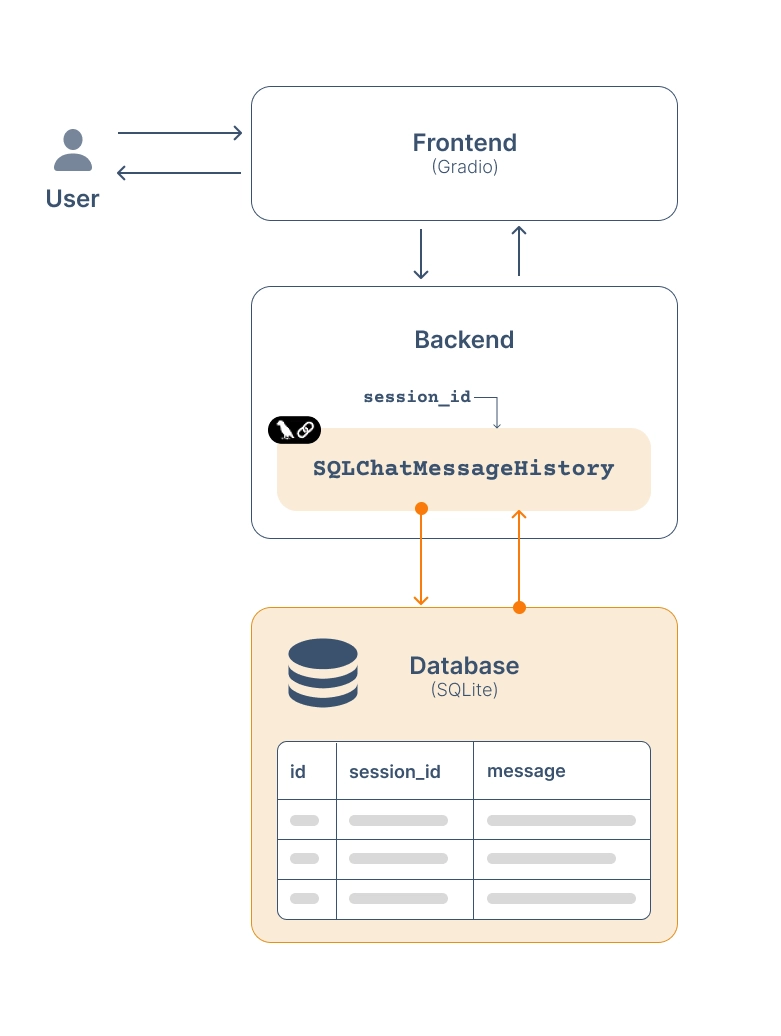

Now, SQLChatMessageHistory is LangChain's abstraction over all of this. Instead of writing SQL yourself, you just:

- Tell it which session ID to use
- Call `add_message()` to store a message
- Call `get_messages()` to retrieve the full conversation

It handles all the SQL under the hood.

The session ID is the glue that ties everything together — it's a unique string assigned to each conversation. When a user returns, we load their session ID, pass it to SQLChatMessageHistory, and it fetches all their previous messages from the database. Think of it like a conversation's fingerprint.

Here's the persistence flow step by step:

1. A new conversation starts → a unique session ID is generated
2. Each message (user and AI) is stored in the database via SQLChatMessageHistory
3. The model always receives the full history from the database, not a Python list in memory
4. When the user returns → we load the session by ID and resume seamlessly

Clear so far?

`yes` 

Let's see persistence in action. Here's the Main tab for the persistent chatbot — same structure as before, but with persistence added under the hood.

Run the code, then:

1. Expand the output pane all the way up
2. Start a conversation and exchange a couple of messages
3. Click "New Chat" and start a second conversation
4. Use the dropdown to switch between your two conversations

Click Continue when you're ready to explore how it works.

In [7]:
os.chdir('..')

In [9]:
%%writefile diet_chat_bot_streaming/main.py
from logic import DietChatBot
from ui import PersistentChatBotUI

# Initialize the chatbot
diet_chatbot = DietChatBot()

# Create and launch the UI with persistence
chatbot_ui = PersistentChatBotUI(diet_chatbot)
interface = chatbot_ui.create_ui()
interface.launch()

Overwriting diet_chat_bot_streaming/main.py


In [10]:
%%writefile diet_chat_bot_streaming/logic.py
import datetime
import sqlite3
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, BaseMessage
from langchain_community.chat_message_histories import SQLChatMessageHistory
from dotenv import load_dotenv
from typing import List, Optional

# Load environment variables
load_dotenv()

# Constants
DEFAULT_MODEL = "gpt-4o-mini"
DB_CONNECTION_STRING = "sqlite:///conversations.db"


SYSTEM_MESSAGE = (
    "You are a diet planning assistant. Help users create balanced meal plans "
    "based on their goals, dietary needs, and preferences. Ask about one topic "
    "at a time to avoid overwhelming the user."
)


class DietChatBot:
    def __init__(self, session_id: Optional[str] = None):
        """Initialize the Diet Chatbot."""
        self.model = init_chat_model(model=DEFAULT_MODEL, temperature=0)
        self.system_msg = SystemMessage(content=SYSTEM_MESSAGE)

        self._initialize_session(session_id)
        self._initialize_history()

    def _initialize_session(self, session_id: Optional[str] = None) -> None:
        """Initialize the session."""
        self.session_id = self._generate_session_id() if not session_id else session_id

    def _generate_session_id(self) -> str:
        """Generate a new session ID with timestamp."""
        timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        return f"Diet Chat - {timestamp}"

    def _initialize_history(self) -> None:
        """Initialize or load the conversation for the current session."""
        self.history = SQLChatMessageHistory(
            session_id=self.session_id, connection_string=DB_CONNECTION_STRING
        )
        if not self.history.get_messages():
            self.history.add_message(self.system_msg)

    def get_response(self, user_message: str) -> str:
        """Process user message and get AI response."""
        # Check if message is empty
        if not (user_message := user_message.strip()):
            return ""

        # Add user message to history
        self.history.add_message(HumanMessage(content=user_message))

        # Get response
        response = self.model.invoke(self.history.get_messages())

        # Add AI response to history
        self.history.add_message(AIMessage(content=response.text))

        return response.text

    def new_session(self) -> None:
        """Create a new conversation."""
        self._initialize_session()
        self._initialize_history()

    def load_session(self, session_id: str) -> None:
        """Load an existing conversation."""
        if not session_id:
            return

        self._initialize_session(session_id)
        self._initialize_history()

    def get_messages(self) -> List[BaseMessage]:
        """Get all messages from the current session."""
        return self.history.get_messages()

    @staticmethod
    def get_previous_conversations() -> List[str]:
        """Get a list of all available conversations."""
        # SQL Query to get previous conversations with more than just the system message
        query = """
        SELECT session_id FROM message_store 
        GROUP BY session_id 
        HAVING COUNT(*) > 1
        ORDER BY session_id DESC
        """

        # Get the database path from the connection string
        db_path = DB_CONNECTION_STRING.replace("sqlite:///", "")
        with sqlite3.connect(db_path) as conn:
            cursor = conn.cursor()
        cursor.execute(query)
        return [row[0] for row in cursor.fetchall()]

Overwriting diet_chat_bot_streaming/logic.py


Let's look at the persistence logic. You already know the basic DietChatBot structure well — this version adds persistence on top of it.

Take a look at the Logic tab here and tell me: can you spot what's new compared to the basic version, or would you prefer a step-by-step walkthrough?

Let's walk through what's changed. The basic chatbot's __init__ set up the model, system message, and self.messages list — that's it. The persistent version's __init__ does the same for the model and system message, but then delegates to two new methods:

- `_initialize_session` — sets up the session ID
- `_initialize_history` — sets up the database connection
  
Instead of a simple self.messages = [...] list, we now have a full session management system. Clear so far?